# DL Lab HW05 - Autoencoder and Variational Autoencoder

이 노트북은 `Todo.md`의 문제 1~3을 수행하기 위한 실험 노트북이다.

FashionMNIST 데이터셋에 대해 Autoencoder(AE)와 Variational Autoencoder(VAE)를 구현하고, latent dimension이 복원 품질과 latent space 구조에 미치는 영향을 비교한다.

Colab에서 실행할 때는 `런타임 > 런타임 유형 변경 > GPU`를 선택한 뒤 위에서부터 실행한다. Colab에서는 기본적으로 Google Drive를 마운트하고 결과를 `/content/drive/MyDrive/DL26/hw05/results_hw05`에 저장한다. CPU 런타임에서는 자동으로 fast debug mode가 켜져 epoch와 batch 수를 줄인 smoke 실행만 수행한다. 제출용 결과를 만들 때는 GPU 런타임에서 `COLAB_FAST_DEV_RUN = False`, `MAX_TRAIN_BATCHES = None`, `MAX_EVAL_BATCHES = None` 상태로 실행한다.

| 문제 | 비교 대상 | 고정 조건 |
| --- | --- | --- |
| 문제 1 | AE latent dim 2/8/32 | 784 -> 256 -> 128 -> latent -> 128 -> 256 -> 784 |
| 문제 2 | VAE latent dim 2/8/32 | AE와 같은 hidden 구조, reconstruction loss + beta * KL |
| 문제 3 | Classifier 기반 생성 이미지 검증 | FashionMNIST classifier로 VAE sample의 confidence/class distribution 측정 |


In [1]:
import json
import os
import random
from collections.abc import Iterable
from contextlib import nullcontext
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


BASE_SEED = 42
LATENT_DIMS = [2, 8, 32]
IMAGE_SHAPE = (1, 28, 28)
FLAT_DIM = 28 * 28
NUM_CLASSES = 10

try:
    import google.colab  # type: ignore[import-not-found]

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = "COLAB_GPU" in os.environ


def set_global_seed(seed_value: int) -> None:
    random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(BASE_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

NUM_WORKERS = 2 if device.type == "cuda" else 0
MOUNT_GOOGLE_DRIVE_IN_COLAB = IN_COLAB
GOOGLE_DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/DL26/hw05")

if IN_COLAB:
    data_dir = Path("/content/data")
    if MOUNT_GOOGLE_DRIVE_IN_COLAB:
        try:
            from google.colab import drive  # type: ignore[import-not-found]

            drive.mount("/content/drive")
            output_dir = GOOGLE_DRIVE_PROJECT_DIR / "results_hw05"
        except Exception as exc:
            print(f"Google Drive mount failed. Falling back to /content/results_hw05. Reason: {exc}")
            output_dir = Path("/content/results_hw05")
    else:
        output_dir = Path("/content/results_hw05")
else:
    project_dir = Path("hw05") if Path("hw05/Todo.md").exists() else Path(".")
    data_dir = project_dir / "data"
    output_dir = project_dir / "results_hw05"

data_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

RUN_PROBLEM_1 = True
RUN_PROBLEM_2 = True
RUN_PROBLEM_3 = True

COLAB_FAST_DEV_RUN = IN_COLAB and device.type != "cuda"
MAX_TRAIN_BATCHES = 2 if COLAB_FAST_DEV_RUN else None
MAX_EVAL_BATCHES = 2 if COLAB_FAST_DEV_RUN else None
USE_AMP = torch.cuda.is_available()
AMP_INIT_SCALE = 1024.0


def experiment_epochs(full_epochs: int) -> int:
    return 1 if COLAB_FAST_DEV_RUN else full_epochs


def experiment_batch_size(full_batch_size: int, fast_batch_size: int = 64) -> int:
    return fast_batch_size if COLAB_FAST_DEV_RUN else full_batch_size


print("Using device:", device)
print("Running in Colab:", IN_COLAB)
print("Mount Google Drive in Colab:", MOUNT_GOOGLE_DRIVE_IN_COLAB)
if IN_COLAB and MOUNT_GOOGLE_DRIVE_IN_COLAB:
    print("Google Drive result directory:", GOOGLE_DRIVE_PROJECT_DIR / "results_hw05")
print("DataLoader workers:", NUM_WORKERS)
print("Data directory:", data_dir.resolve())
print("Output directory:", output_dir.resolve())
print("MAX_TRAIN_BATCHES:", MAX_TRAIN_BATCHES)
print("MAX_EVAL_BATCHES:", MAX_EVAL_BATCHES)
print("Automatic mixed precision:", USE_AMP)
print("Problem 3 enabled:", RUN_PROBLEM_3)


Using device: cuda
Running in Colab: False
Mount Google Drive in Colab: False
DataLoader workers: 2
Data directory: /home/ilhyeonchu/Documents/GitHub/DL26/hw05/data
Output directory: /home/ilhyeonchu/Documents/GitHub/DL26/hw05/results_hw05
MAX_TRAIN_BATCHES: None
MAX_EVAL_BATCHES: None
Automatic mixed precision: True
Problem 3 enabled: True


## 공통 데이터 구성

- FashionMNIST train 60,000장과 test 10,000장을 사용한다.
- AE/VAE의 출력 layer에 sigmoid를 사용하므로 입력 이미지는 `[0, 1]` 범위의 tensor로 유지한다.
- 비교 공정성을 위해 AE와 VAE 모두 같은 DataLoader, optimizer 계열, learning rate, scheduler, epoch 수를 사용한다.


In [2]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root=str(data_dir),
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=str(data_dir),
    train=False,
    download=True,
    transform=transform,
)


def make_loader(dataset: torch.utils.data.Dataset, batch_size: int, shuffle: bool, seed_offset: int) -> DataLoader:
    generator = torch.Generator().manual_seed(BASE_SEED + seed_offset) if shuffle else None
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=NUM_WORKERS > 0,
    )


BATCH_SIZE = experiment_batch_size(256)
train_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, seed_offset=1)
test_loader = make_loader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, seed_offset=2)

print(f"FashionMNIST train samples: {len(train_dataset):,}")
print(f"FashionMNIST test samples: {len(test_dataset):,}")
print("Batch size:", BATCH_SIZE)
print("Classes:", class_names)


FashionMNIST train samples: 60,000
FashionMNIST test samples: 10,000
Batch size: 256
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 모델 정의

AE와 VAE 모두 권장 구조인 `784 -> 256 -> 128 -> latent_dim -> 128 -> 256 -> 784`를 따른다.

VAE는 encoder의 마지막에서 `mu`와 `log_var`를 각각 출력하고, reparameterization trick으로 sampling한 `z`를 decoder에 입력한다.


In [3]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim: int) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(FLAT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, FLAT_DIM),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x_flat = x.view(x.size(0), -1)
        z = self.encoder(x_flat)
        reconstruction = self.decoder(z).view(x.size(0), *IMAGE_SHAPE)
        return reconstruction, z


class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim: int) -> None:
        super().__init__()
        self.encoder_backbone = nn.Sequential(
            nn.Linear(FLAT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.mu_layer = nn.Linear(128, latent_dim)
        self.log_var_layer = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, FLAT_DIM),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x_flat = x.view(x.size(0), -1)
        hidden = self.encoder_backbone(x_flat)
        return self.mu_layer(hidden), self.log_var_layer(hidden)

    @staticmethod
    def reparameterize(mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z).view(z.size(0), *IMAGE_SHAPE)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decode(z)
        return reconstruction, mu, log_var, z


def count_parameters(model: nn.Module, trainable_only: bool = False) -> int:
    parameters: Iterable[torch.nn.Parameter] = model.parameters()
    if trainable_only:
        parameters = (param for param in parameters if param.requires_grad)
    return sum(param.numel() for param in parameters)


for latent_dim in LATENT_DIMS:
    ae = Autoencoder(latent_dim)
    vae = VariationalAutoencoder(latent_dim)
    print(
        f"latent_dim={latent_dim}: "
        f"AE params={count_parameters(ae):,}, VAE params={count_parameters(vae):,}"
    )


latent_dim=2: AE params=469,010, VAE params=469,268
latent_dim=8: AE params=470,552, VAE params=471,584
latent_dim=32: AE params=476,720, VAE params=480,848


## 공통 학습/평가 및 시각화 함수


In [4]:
def reconstruction_loss(reconstruction: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(reconstruction, x, reduction="mean")


def vae_loss(
    reconstruction: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    log_var: torch.Tensor,
    beta: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    recon = reconstruction_loss(reconstruction, x)
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1).mean()
    loss = recon + beta * kl
    return loss, recon, kl


def amp_context():
    if USE_AMP:
        return torch.autocast(device_type=device.type, dtype=torch.float16)
    return nullcontext()


def train_ae(
    latent_dim: int,
    epochs: int,
    learning_rate: float,
    weight_decay: float,
) -> tuple[Autoencoder, dict]:
    set_global_seed(BASE_SEED + latent_dim)
    model = Autoencoder(latent_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", init_scale=AMP_INIT_SCALE, enabled=USE_AMP)

    history = {
        "latent_dim": latent_dim,
        "parameters": count_parameters(model),
        "train_recon_loss": [],
        "test_recon_loss": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_sample_count = 0

        for batch_idx, (x, _) in enumerate(train_loader):
            if MAX_TRAIN_BATCHES is not None and batch_idx >= MAX_TRAIN_BATCHES:
                break
            x = x.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with amp_context():
                reconstruction, _ = model(x)
                loss = reconstruction_loss(reconstruction, x)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = x.size(0)
            train_loss_sum += loss.detach().item() * batch_size
            train_sample_count += batch_size

        scheduler.step()
        test_loss = evaluate_ae(model)
        train_loss = train_loss_sum / train_sample_count
        history["train_recon_loss"].append(train_loss)
        history["test_recon_loss"].append(test_loss)
        print(
            f"[AE latent={latent_dim}] epoch {epoch:02d}/{epochs} "
            f"train_recon={train_loss:.6f} test_recon={test_loss:.6f}"
        )

    return model, history


@torch.no_grad()
def evaluate_ae(model: Autoencoder) -> float:
    model.eval()
    loss_sum = 0.0
    sample_count = 0
    for batch_idx, (x, _) in enumerate(test_loader):
        if MAX_EVAL_BATCHES is not None and batch_idx >= MAX_EVAL_BATCHES:
            break
        x = x.to(device, non_blocking=True)
        with amp_context():
            reconstruction, _ = model(x)
            loss = reconstruction_loss(reconstruction, x)
        batch_size = x.size(0)
        loss_sum += loss.item() * batch_size
        sample_count += batch_size
    return loss_sum / sample_count


def train_vae(
    latent_dim: int,
    epochs: int,
    learning_rate: float,
    weight_decay: float,
    beta: float,
) -> tuple[VariationalAutoencoder, dict]:
    set_global_seed(BASE_SEED + 100 + latent_dim)
    model = VariationalAutoencoder(latent_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", init_scale=AMP_INIT_SCALE, enabled=USE_AMP)

    history = {
        "latent_dim": latent_dim,
        "parameters": count_parameters(model),
        "beta": beta,
        "train_total_loss": [],
        "train_recon_loss": [],
        "train_kl_loss": [],
        "test_total_loss": [],
        "test_recon_loss": [],
        "test_kl_loss": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        total_sum = 0.0
        recon_sum = 0.0
        kl_sum = 0.0
        sample_count = 0

        for batch_idx, (x, _) in enumerate(train_loader):
            if MAX_TRAIN_BATCHES is not None and batch_idx >= MAX_TRAIN_BATCHES:
                break
            x = x.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with amp_context():
                reconstruction, mu, log_var, _ = model(x)
                loss, recon, kl = vae_loss(reconstruction, x, mu, log_var, beta)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = x.size(0)
            total_sum += loss.detach().item() * batch_size
            recon_sum += recon.detach().item() * batch_size
            kl_sum += kl.detach().item() * batch_size
            sample_count += batch_size

        scheduler.step()
        test_metrics = evaluate_vae(model, beta)
        history["train_total_loss"].append(total_sum / sample_count)
        history["train_recon_loss"].append(recon_sum / sample_count)
        history["train_kl_loss"].append(kl_sum / sample_count)
        history["test_total_loss"].append(test_metrics["total"])
        history["test_recon_loss"].append(test_metrics["recon"])
        history["test_kl_loss"].append(test_metrics["kl"])
        print(
            f"[VAE latent={latent_dim}] epoch {epoch:02d}/{epochs} "
            f"train_total={history['train_total_loss'][-1]:.6f} "
            f"test_total={test_metrics['total']:.6f} "
            f"test_recon={test_metrics['recon']:.6f} test_kl={test_metrics['kl']:.6f}"
        )

    return model, history


@torch.no_grad()
def evaluate_vae(model: VariationalAutoencoder, beta: float) -> dict[str, float]:
    model.eval()
    total_sum = 0.0
    recon_sum = 0.0
    kl_sum = 0.0
    sample_count = 0

    for batch_idx, (x, _) in enumerate(test_loader):
        if MAX_EVAL_BATCHES is not None and batch_idx >= MAX_EVAL_BATCHES:
            break
        x = x.to(device, non_blocking=True)
        with amp_context():
            reconstruction, mu, log_var, _ = model(x)
            loss, recon, kl = vae_loss(reconstruction, x, mu, log_var, beta)
        batch_size = x.size(0)
        total_sum += loss.item() * batch_size
        recon_sum += recon.item() * batch_size
        kl_sum += kl.item() * batch_size
        sample_count += batch_size

    return {
        "total": total_sum / sample_count,
        "recon": recon_sum / sample_count,
        "kl": kl_sum / sample_count,
    }


def save_json(payload: dict, path: Path) -> None:
    path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
    print("Saved:", path)


In [5]:
def plot_ae_loss_curves(histories: dict[int, dict], path: Path) -> None:
    plt.figure(figsize=(8, 5))
    for latent_dim, history in histories.items():
        epochs = range(1, len(history["train_recon_loss"]) + 1)
        plt.plot(epochs, history["train_recon_loss"], linestyle="--", label=f"latent {latent_dim} train")
        plt.plot(epochs, history["test_recon_loss"], label=f"latent {latent_dim} test")
    plt.xlabel("Epoch")
    plt.ylabel("MSE reconstruction loss")
    plt.title("AE Reconstruction Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)


def plot_vae_loss_curves(histories: dict[int, dict], path: Path) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = [
        ("total_loss", "Total loss"),
        ("recon_loss", "Reconstruction loss"),
        ("kl_loss", "KL divergence"),
    ]
    for axis, (metric_suffix, title) in zip(axes, metrics, strict=True):
        for latent_dim, history in histories.items():
            epochs = range(1, len(history[f"train_{metric_suffix}"]) + 1)
            axis.plot(epochs, history[f"train_{metric_suffix}"], linestyle="--", label=f"latent {latent_dim} train")
            axis.plot(epochs, history[f"test_{metric_suffix}"], label=f"latent {latent_dim} test")
        axis.set_xlabel("Epoch")
        axis.set_title(title)
        axis.grid(alpha=0.3)
    axes[0].set_ylabel("Loss")
    axes[-1].legend(loc="best", fontsize=8)
    fig.suptitle("VAE Loss Components")
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)


@torch.no_grad()
def collect_reconstructions(model: nn.Module, model_type: str, sample_count: int = 8) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    model.eval()
    x, labels = next(iter(test_loader))
    x = x[:sample_count].to(device)
    if model_type == "ae":
        reconstruction, _ = model(x)
    elif model_type == "vae":
        reconstruction, _, _, _ = model(x)
    else:
        raise ValueError(f"Unsupported model_type: {model_type}")
    return x.cpu(), reconstruction.cpu(), labels[:sample_count].cpu()


def plot_reconstruction_grid(
    originals: torch.Tensor,
    reconstructions: torch.Tensor,
    labels: torch.Tensor,
    path: Path,
    title: str,
) -> None:
    sample_count = originals.size(0)
    fig, axes = plt.subplots(2, sample_count, figsize=(1.6 * sample_count, 3.5))
    for idx in range(sample_count):
        axes[0, idx].imshow(originals[idx, 0], cmap="gray")
        axes[0, idx].set_title(class_names[int(labels[idx])], fontsize=8)
        axes[0, idx].axis("off")
        axes[1, idx].imshow(reconstructions[idx, 0], cmap="gray")
        axes[1, idx].axis("off")
    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Recon")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)


@torch.no_grad()
def collect_latent_2d(model: nn.Module, model_type: str, max_batches: int | None = None) -> tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    latent_parts = []
    label_parts = []
    for batch_idx, (x, labels) in enumerate(test_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        if model_type == "ae":
            _, z = model(x)
        elif model_type == "vae":
            mu, _ = model.encode(x)
            z = mu
        else:
            raise ValueError(f"Unsupported model_type: {model_type}")
        latent_parts.append(z.cpu())
        label_parts.append(labels)
    return torch.cat(latent_parts), torch.cat(label_parts)


def plot_latent_space(latents: torch.Tensor, labels: torch.Tensor, path: Path, title: str) -> None:
    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        latents[:, 0].numpy(),
        latents[:, 1].numpy(),
        c=labels.numpy(),
        cmap="tab10",
        s=6,
        alpha=0.65,
    )
    colorbar = plt.colorbar(scatter, ticks=list(range(NUM_CLASSES)))
    colorbar.ax.set_yticklabels(class_names)
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)


## 문제 1. Autoencoder 구현

latent dimension 2, 8, 32에 대해 같은 AE 구조를 학습한다.


[AE latent=2] epoch 01/15 train_recon=0.048741 test_recon=0.032634


[AE latent=2] epoch 02/15 train_recon=0.031299 test_recon=0.030166


[AE latent=2] epoch 03/15 train_recon=0.029709 test_recon=0.029017


[AE latent=2] epoch 04/15 train_recon=0.028866 test_recon=0.028507


[AE latent=2] epoch 05/15 train_recon=0.028276 test_recon=0.028338


...

[AE latent=32] epoch 11/15 train_recon=0.014611 test_recon=0.014624


[AE latent=32] epoch 12/15 train_recon=0.014415 test_recon=0.014476


[AE latent=32] epoch 13/15 train_recon=0.014279 test_recon=0.014364


[AE latent=32] epoch 14/15 train_recon=0.014196 test_recon=0.014308


[AE latent=32] epoch 15/15 train_recon=0.014155 test_recon=0.014283
Saved: results_hw05/problem1_ae_results.json


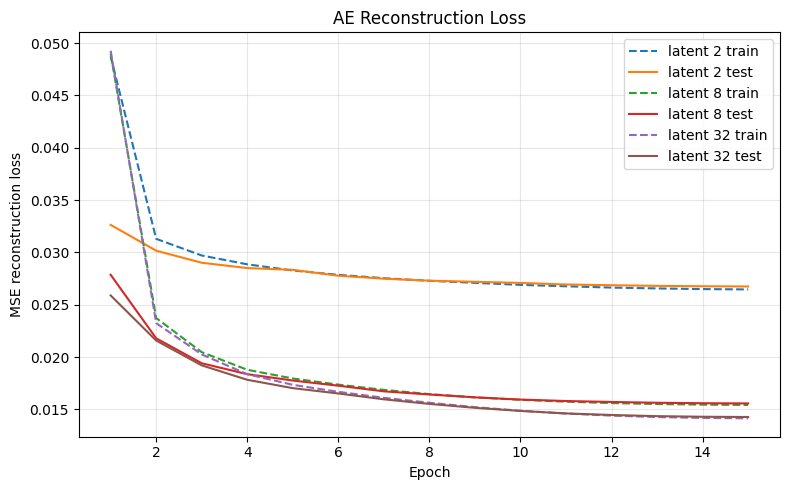

Saved: results_hw05/problem1_ae_reconstruction_loss.png


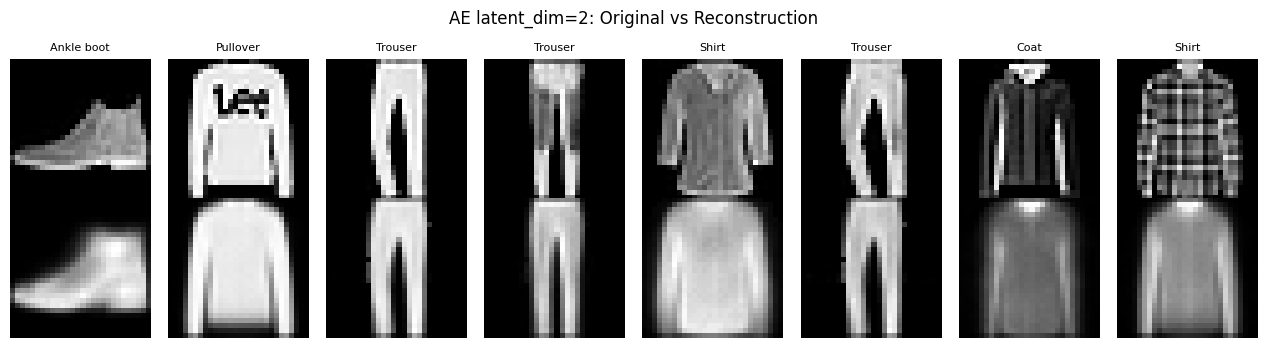

Saved: results_hw05/problem1_ae_latent_2_reconstructions.png


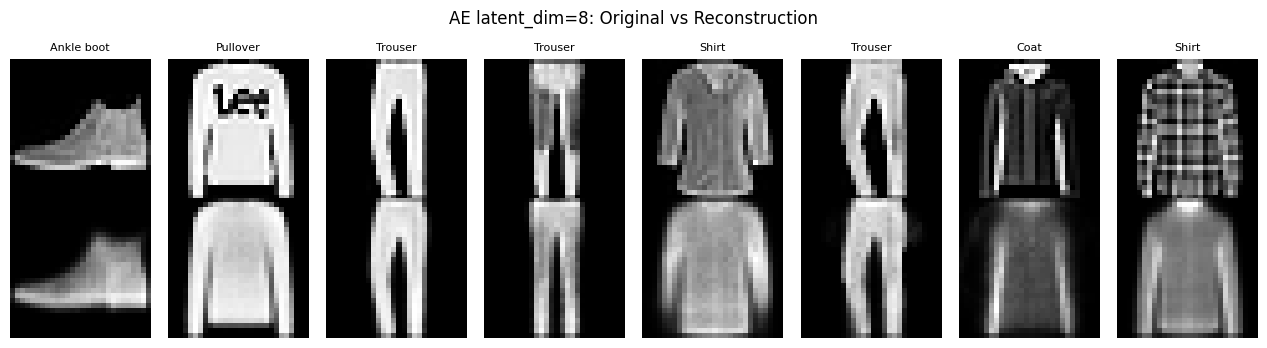

Saved: results_hw05/problem1_ae_latent_8_reconstructions.png


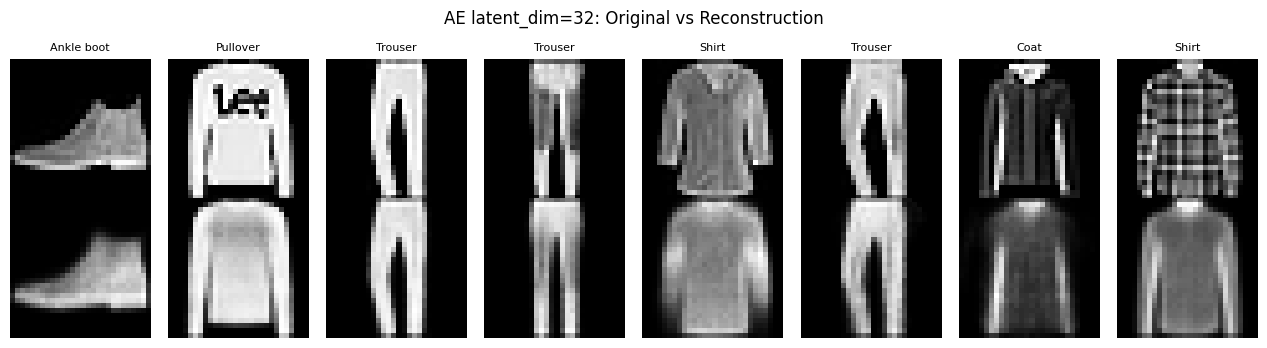

Saved: results_hw05/problem1_ae_latent_32_reconstructions.png


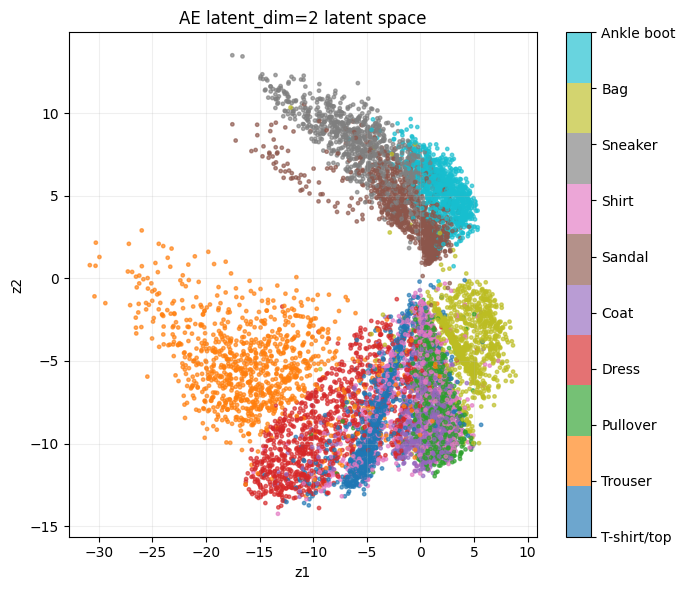

Saved: results_hw05/problem1_ae_latent_2_space.png


In [6]:
AE_EPOCHS = experiment_epochs(15)
AE_LR = 1e-3
AE_WEIGHT_DECAY = 1e-5

ae_models: dict[int, Autoencoder] = {}
ae_histories: dict[int, dict] = {}

if RUN_PROBLEM_1:
    for latent_dim in LATENT_DIMS:
        model, history = train_ae(
            latent_dim=latent_dim,
            epochs=AE_EPOCHS,
            learning_rate=AE_LR,
            weight_decay=AE_WEIGHT_DECAY,
        )
        ae_models[latent_dim] = model
        ae_histories[latent_dim] = history

    save_json(ae_histories, output_dir / "problem1_ae_results.json")
    plot_ae_loss_curves(ae_histories, output_dir / "problem1_ae_reconstruction_loss.png")

    for latent_dim, model in ae_models.items():
        originals, reconstructions, labels = collect_reconstructions(model, model_type="ae", sample_count=8)
        plot_reconstruction_grid(
            originals=originals,
            reconstructions=reconstructions,
            labels=labels,
            path=output_dir / f"problem1_ae_latent_{latent_dim}_reconstructions.png",
            title=f"AE latent_dim={latent_dim}: Original vs Reconstruction",
        )

    latents, labels = collect_latent_2d(ae_models[2], model_type="ae")
    plot_latent_space(
        latents=latents,
        labels=labels,
        path=output_dir / "problem1_ae_latent_2_space.png",
        title="AE latent_dim=2 latent space",
    )


### 문제 1 분석 초안

- latent dimension이 커질수록 encoder가 보존할 수 있는 정보량이 증가하므로 일반적으로 reconstruction loss가 낮아지고 복원 이미지의 윤곽과 세부 형태가 더 선명해진다.
- `latent_dim=2`는 시각화가 가능하지만 정보 병목이 강해 복원 품질이 가장 낮을 가능성이 높다.
- `latent_dim=8`은 2차원보다 클래스별 형태 정보를 더 안정적으로 보존하지만, 세밀한 질감이나 일부 혼동되는 클래스는 여전히 흐려질 수 있다.
- `latent_dim=32`는 가장 큰 latent capacity를 가지므로 원본과 가까운 복원을 기대할 수 있다. 단, latent dimension 외 조건을 동일하게 유지했으므로 개선은 주로 표현 용량 증가의 효과로 해석한다.
- 2D latent space에서는 신발류, 상의류처럼 형태가 다른 클래스는 비교적 분리되고, `T-shirt/top`, `Shirt`, `Pullover`, `Coat`처럼 시각적으로 유사한 클래스는 일부 겹칠 수 있다.


## 문제 2. Variational Autoencoder 구현

AE와 같은 hidden 구조를 사용하되, encoder가 `mu`와 `log_var`를 출력하도록 바꾼다. VAE loss는 reconstruction loss와 KL divergence를 분리해 기록한다.


[VAE latent=2] epoch 01/15 train_total=0.052431 test_total=0.036011 test_recon=0.034875 test_kl=11.368517


[VAE latent=2] epoch 02/15 train_total=0.034741 test_total=0.033503 test_recon=0.032459 test_kl=10.446924


[VAE latent=2] epoch 03/15 train_total=0.032751 test_total=0.031933 test_recon=0.030923 test_kl=10.102869


[VAE latent=2] epoch 04/15 train_total=0.031453 test_total=0.030861 test_recon=0.029876 test_kl=9.842668


[VAE latent=2] epoch 05/15 train_total=0.030430 test_total=0.029971 test_recon=0.028967 test_kl=10.047219


...

[VAE latent=32] epoch 11/15 train_total=0.018109 test_total=0.018125 test_recon=0.015448 test_kl=26.770502


[VAE latent=32] epoch 12/15 train_total=0.017921 test_total=0.017981 test_recon=0.015311 test_kl=26.706874


[VAE latent=32] epoch 13/15 train_total=0.017798 test_total=0.017878 test_recon=0.015228 test_kl=26.500428


[VAE latent=32] epoch 14/15 train_total=0.017724 test_total=0.017819 test_recon=0.015149 test_kl=26.700551


[VAE latent=32] epoch 15/15 train_total=0.017688 test_total=0.017811 test_recon=0.015138 test_kl=26.731557
Saved: results_hw05/problem2_vae_results.json


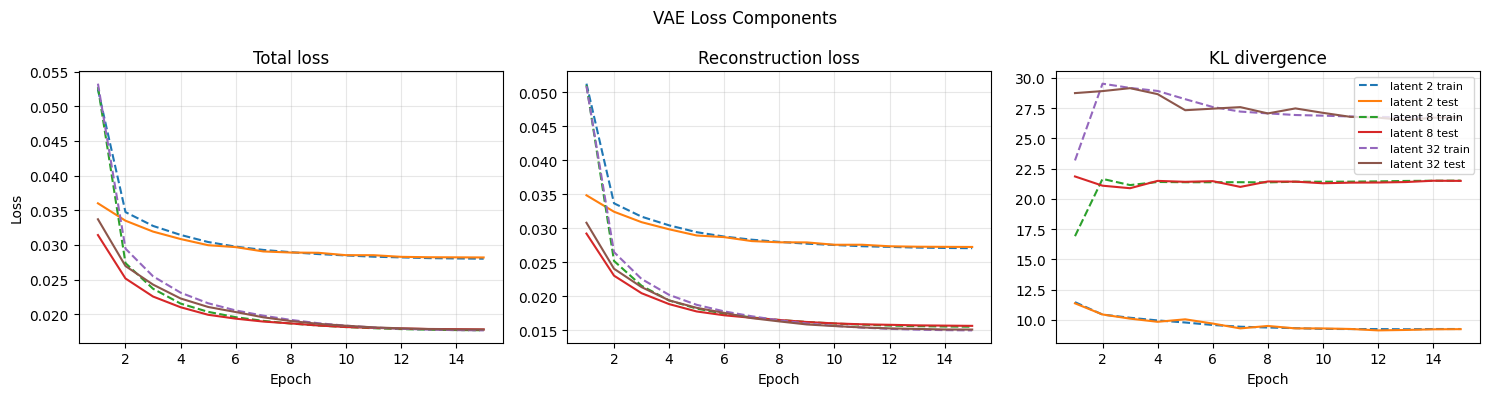

Saved: results_hw05/problem2_vae_loss_components.png


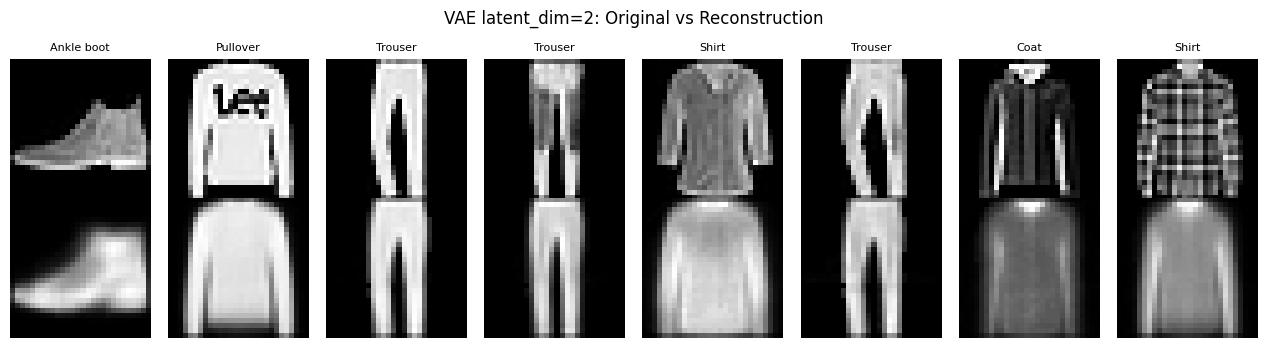

Saved: results_hw05/problem2_vae_latent_2_reconstructions.png


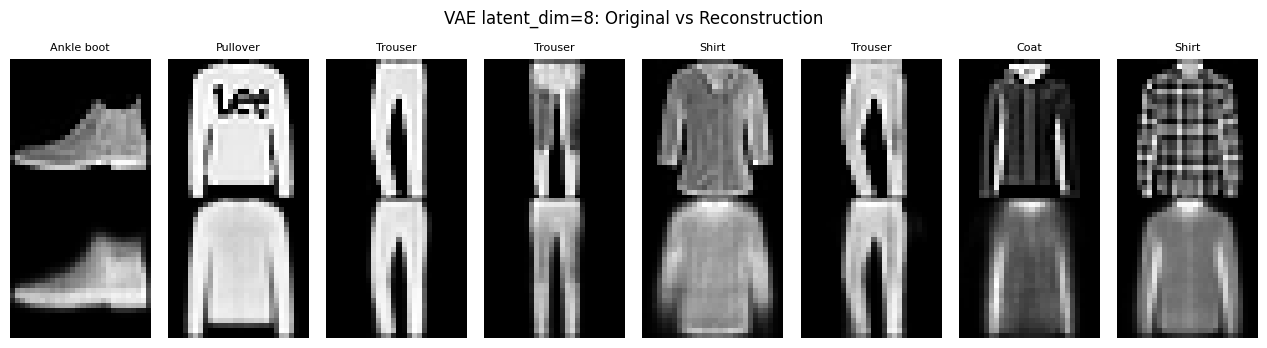

Saved: results_hw05/problem2_vae_latent_8_reconstructions.png


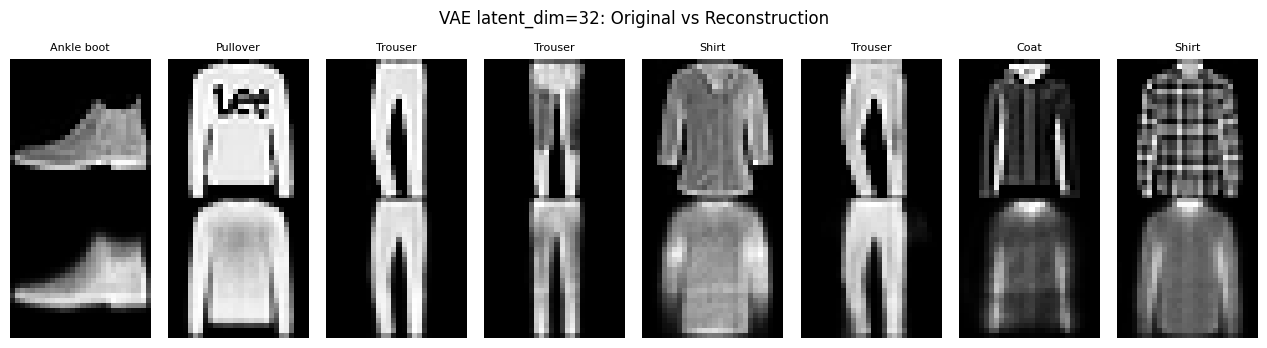

Saved: results_hw05/problem2_vae_latent_32_reconstructions.png


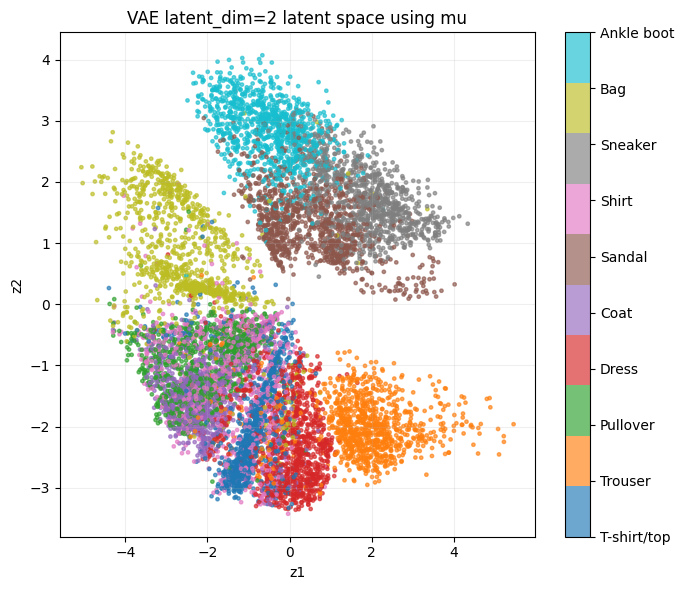

Saved: results_hw05/problem2_vae_latent_2_space.png


In [7]:
VAE_EPOCHS = experiment_epochs(15)
VAE_LR = 1e-3
VAE_WEIGHT_DECAY = 1e-5
VAE_BETA = 1e-4

vae_models: dict[int, VariationalAutoencoder] = {}
vae_histories: dict[int, dict] = {}

if RUN_PROBLEM_2:
    for latent_dim in LATENT_DIMS:
        model, history = train_vae(
            latent_dim=latent_dim,
            epochs=VAE_EPOCHS,
            learning_rate=VAE_LR,
            weight_decay=VAE_WEIGHT_DECAY,
            beta=VAE_BETA,
        )
        vae_models[latent_dim] = model
        vae_histories[latent_dim] = history

    save_json(vae_histories, output_dir / "problem2_vae_results.json")
    plot_vae_loss_curves(vae_histories, output_dir / "problem2_vae_loss_components.png")

    for latent_dim, model in vae_models.items():
        originals, reconstructions, labels = collect_reconstructions(model, model_type="vae", sample_count=8)
        plot_reconstruction_grid(
            originals=originals,
            reconstructions=reconstructions,
            labels=labels,
            path=output_dir / f"problem2_vae_latent_{latent_dim}_reconstructions.png",
            title=f"VAE latent_dim={latent_dim}: Original vs Reconstruction",
        )

    latents, labels = collect_latent_2d(vae_models[2], model_type="vae")
    plot_latent_space(
        latents=latents,
        labels=labels,
        path=output_dir / "problem2_vae_latent_2_space.png",
        title="VAE latent_dim=2 latent space using mu",
    )


In [8]:
def build_ae_vae_comparison_table(ae_histories: dict[int, dict], vae_histories: dict[int, dict]) -> list[dict]:
    rows = []
    for latent_dim in LATENT_DIMS:
        row = {"latent_dim": latent_dim}
        if latent_dim in ae_histories:
            row["ae_test_recon_loss"] = ae_histories[latent_dim]["test_recon_loss"][-1]
            row["ae_parameters"] = ae_histories[latent_dim]["parameters"]
        if latent_dim in vae_histories:
            row["vae_test_total_loss"] = vae_histories[latent_dim]["test_total_loss"][-1]
            row["vae_test_recon_loss"] = vae_histories[latent_dim]["test_recon_loss"][-1]
            row["vae_test_kl_loss"] = vae_histories[latent_dim]["test_kl_loss"][-1]
            row["vae_parameters"] = vae_histories[latent_dim]["parameters"]
        rows.append(row)
    return rows


comparison_rows = build_ae_vae_comparison_table(ae_histories, vae_histories)
save_json({"comparison": comparison_rows}, output_dir / "problem2_ae_vae_comparison.json")
comparison_rows


Saved: results_hw05/problem2_ae_vae_comparison.json


[{'latent_dim': 2,
  'ae_test_recon_loss': 0.026747923773527145,
  'ae_parameters': 469010,
  'vae_test_total_loss': 0.02820366048812866,
  'vae_test_recon_loss': 0.027280169856548308,
  'vae_test_kl_loss': 9.234905853271485,
  'vae_parameters': 469268},
 {'latent_dim': 8,
  'ae_test_recon_loss': 0.015581013861298561,
  'ae_parameters': 470552,
  'vae_test_total_loss': 0.017829641610383987,
  'vae_test_recon_loss': 0.01568146896958351,
  'vae_test_kl_loss': 21.4817287689209,
  'vae_parameters': 471584},
 {'latent_dim': 32,
  'ae_test_recon_loss': 0.014283188357949258,
  'ae_parameters': 476720,
  'vae_test_total_loss': 0.01781085589528084,
  'vae_test_recon_loss': 0.015137700241804122,
  'vae_test_kl_loss': 26.731556561279298,
  'vae_parameters': 480848}]

### 문제 2 분석 초안

- VAE는 AE와 달리 latent vector를 하나의 deterministic code로만 쓰지 않고, `mu`와 `log_var`가 정의하는 확률분포에서 sampling한다.
- KL divergence는 latent distribution이 표준정규분포에 가까워지도록 regularization을 건다. 이 때문에 latent space는 AE보다 연속적이고 부드러운 분포를 갖는 경향이 있다.
- 같은 latent dimension에서 VAE의 reconstruction은 AE보다 흐릴 수 있다. 이는 reconstruction 정확도만 최적화하는 AE와 달리 VAE는 sampling 가능하고 정규화된 latent space도 함께 만족해야 하기 때문이다.
- `latent_dim=2`에서 AE latent space는 class별 cluster가 불규칙하거나 빈 공간이 많을 수 있고, VAE는 KL 항의 영향으로 원점 주변에 더 연속적으로 모이는 경향을 보일 수 있다.
- 최종 보고서에서는 `problem1_ae_results.json`, `problem2_vae_results.json`, `problem2_ae_vae_comparison.json`의 수치와 생성된 reconstruction/latent plot을 근거로 서술한다.


## 문제 3. 생성 모델의 검증

팀 논의에서는 좋은 생성 모델의 기준을 다음 세 가지로 정리했다.

![Problem 3 discussion](q3.png)

- 품질(Quality): 생성 이미지가 실제 FashionMNIST 이미지처럼 보이고, classifier가 높은 confidence로 특정 클래스로 분류할 수 있어야 한다.
- 다양성(Diversity): 특정 패턴만 반복하지 않고 여러 클래스와 형태가 생성되어야 한다.
- 커버리지(Coverage): 실제 데이터에 존재하는 클래스 또는 모드를 고르게 생성해야 한다.

이 노트북에서는 위 기준을 반영하기 위해 classifier 기반 평가를 구현한다. FashionMNIST classifier를 train split으로 학습하고, VAE가 표준정규분포에서 sampling한 latent vector로 생성한 이미지를 classifier에 입력한다. 이후 평균 confidence, high-confidence 비율, 예측 클래스 분포, class entropy, coverage class 수를 측정한다.


In [9]:
class FashionMNISTClassifier(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, NUM_CLASSES),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


def train_classifier(
    epochs: int,
    learning_rate: float,
    weight_decay: float,
) -> tuple[FashionMNISTClassifier, dict]:
    set_global_seed(BASE_SEED + 300)
    model = FashionMNISTClassifier().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", init_scale=AMP_INIT_SCALE, enabled=USE_AMP)

    history = {
        "parameters": count_parameters(model),
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        correct = 0
        sample_count = 0

        for batch_idx, (x, labels) in enumerate(train_loader):
            if MAX_TRAIN_BATCHES is not None and batch_idx >= MAX_TRAIN_BATCHES:
                break
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with amp_context():
                logits = model(x)
                loss = F.cross_entropy(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = x.size(0)
            loss_sum += loss.detach().item() * batch_size
            correct += (logits.argmax(dim=1) == labels).sum().item()
            sample_count += batch_size

        scheduler.step()
        test_metrics = evaluate_classifier(model)
        history["train_loss"].append(loss_sum / sample_count)
        history["train_accuracy"].append(correct / sample_count)
        history["test_loss"].append(test_metrics["loss"])
        history["test_accuracy"].append(test_metrics["accuracy"])
        print(
            f"[Classifier] epoch {epoch:02d}/{epochs} "
            f"train_acc={history['train_accuracy'][-1]:.4f} "
            f"test_acc={test_metrics['accuracy']:.4f}"
        )

    return model, history


@torch.no_grad()
def evaluate_classifier(model: FashionMNISTClassifier) -> dict[str, float]:
    model.eval()
    loss_sum = 0.0
    correct = 0
    sample_count = 0

    for batch_idx, (x, labels) in enumerate(test_loader):
        if MAX_EVAL_BATCHES is not None and batch_idx >= MAX_EVAL_BATCHES:
            break
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with amp_context():
            logits = model(x)
            loss = F.cross_entropy(logits, labels)
        batch_size = x.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        sample_count += batch_size

    return {
        "loss": loss_sum / sample_count,
        "accuracy": correct / sample_count,
    }


In [10]:
@torch.no_grad()
def generate_vae_images(
    model: VariationalAutoencoder,
    latent_dim: int,
    sample_count: int,
    batch_size: int,
) -> torch.Tensor:
    model.eval()
    generated_batches = []
    remaining = sample_count

    while remaining > 0:
        current_batch_size = min(batch_size, remaining)
        z = torch.randn(current_batch_size, latent_dim, device=device)
        images = model.decode(z).clamp(0.0, 1.0)
        generated_batches.append(images.cpu())
        remaining -= current_batch_size

    return torch.cat(generated_batches, dim=0)


@torch.no_grad()
def evaluate_generated_images_with_classifier(
    classifier: FashionMNISTClassifier,
    images: torch.Tensor,
    batch_size: int,
    confidence_threshold: float = 0.8,
) -> dict:
    classifier.eval()
    probability_parts = []

    for start in range(0, images.size(0), batch_size):
        batch = images[start : start + batch_size].to(device, non_blocking=True)
        with amp_context():
            logits = classifier(batch)
            probabilities = torch.softmax(logits, dim=1)
        probability_parts.append(probabilities.cpu())

    probabilities = torch.cat(probability_parts, dim=0)
    confidences, predictions = probabilities.max(dim=1)
    class_counts = torch.bincount(predictions, minlength=NUM_CLASSES).float()
    class_distribution = class_counts / class_counts.sum().clamp_min(1.0)
    nonzero_distribution = class_distribution[class_distribution > 0]
    entropy = -(nonzero_distribution * nonzero_distribution.log()).sum().item()
    normalized_entropy = entropy / torch.log(torch.tensor(float(NUM_CLASSES))).item()

    return {
        "sample_count": int(images.size(0)),
        "mean_confidence": float(confidences.mean().item()),
        "median_confidence": float(confidences.median().item()),
        "high_confidence_threshold": confidence_threshold,
        "high_confidence_rate": float((confidences >= confidence_threshold).float().mean().item()),
        "coverage_class_count": int((class_counts > 0).sum().item()),
        "class_entropy": float(entropy),
        "normalized_class_entropy": float(normalized_entropy),
        "class_counts": [int(value) for value in class_counts.tolist()],
        "class_distribution": [float(value) for value in class_distribution.tolist()],
    }


def plot_generated_samples(
    images: torch.Tensor,
    path: Path,
    title: str,
    sample_count: int = 40,
) -> None:
    selected = images[:sample_count]
    columns = 10
    rows = (selected.size(0) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(columns, rows))
    axes = axes.reshape(rows, columns)

    for idx in range(rows * columns):
        row = idx // columns
        column = idx % columns
        axes[row, column].axis("off")
        if idx < selected.size(0):
            axes[row, column].imshow(selected[idx, 0], cmap="gray")

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)


def plot_class_distribution(metrics_by_name: dict[str, dict], path: Path) -> None:
    x = torch.arange(NUM_CLASSES).numpy()
    width = 0.8 / max(len(metrics_by_name), 1)
    plt.figure(figsize=(10, 5))

    for idx, (name, metrics) in enumerate(metrics_by_name.items()):
        offset = (idx - (len(metrics_by_name) - 1) / 2) * width
        plt.bar(
            x + offset,
            metrics["class_distribution"],
            width=width,
            label=name,
        )

    plt.xticks(x, class_names, rotation=30, ha="right")
    plt.ylabel("Predicted class probability")
    plt.title("Classifier-predicted distribution of VAE generated images")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)


def plot_problem3_metric_bars(metrics_by_name: dict[str, dict], path: Path) -> None:
    names = list(metrics_by_name)
    metric_names = ["mean_confidence", "high_confidence_rate", "normalized_class_entropy"]
    fig, axes = plt.subplots(1, len(metric_names), figsize=(12, 4))

    for axis, metric_name in zip(axes, metric_names, strict=True):
        values = [metrics_by_name[name][metric_name] for name in names]
        axis.bar(names, values)
        axis.set_ylim(0.0, 1.0)
        axis.set_title(metric_name)
        axis.tick_params(axis="x", rotation=20)
        axis.grid(axis="y", alpha=0.3)

    fig.suptitle("Problem 3 classifier-based generation metrics")
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)


[Classifier] epoch 01/5 train_acc=0.8395 test_acc=0.8911


[Classifier] epoch 02/5 train_acc=0.8966 test_acc=0.8977


[Classifier] epoch 03/5 train_acc=0.9139 test_acc=0.9069


[Classifier] epoch 04/5 train_acc=0.9254 test_acc=0.9143


[Classifier] epoch 05/5 train_acc=0.9344 test_acc=0.9192


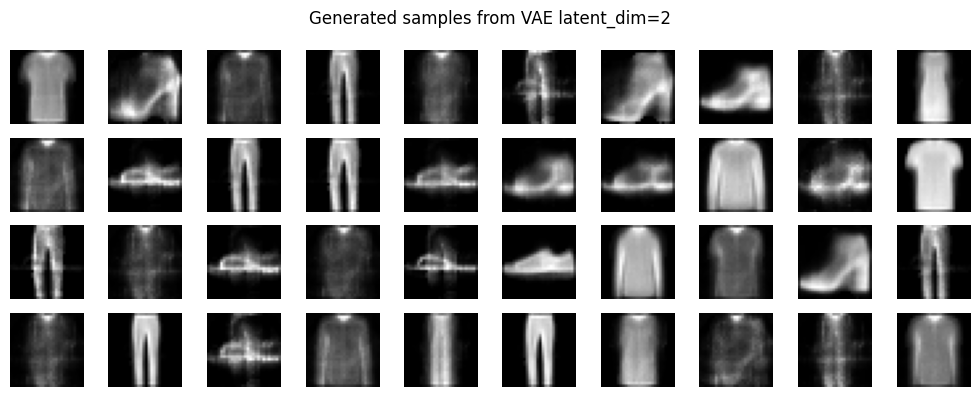

Saved: results_hw05/problem3_generated_samples_latent_2.png
VAE latent 2 {'sample_count': 1000, 'mean_confidence': 0.7033578157424927, 'median_confidence': 0.7324241995811462, 'high_confidence_threshold': 0.8, 'high_confidence_rate': 0.40799999237060547, 'coverage_class_count': 8, 'class_entropy': 1.9316542148590088, 'normalized_class_entropy': 0.8389067548087328, 'class_counts': [254, 64, 150, 35, 0, 67, 0, 184, 106, 140], 'class_distribution': [0.2540000081062317, 0.06400000303983688, 0.15000000596046448, 0.03500000014901161, 0.0, 0.06700000166893005, 0.0, 0.18400000035762787, 0.10599999874830246, 0.14000000059604645]}


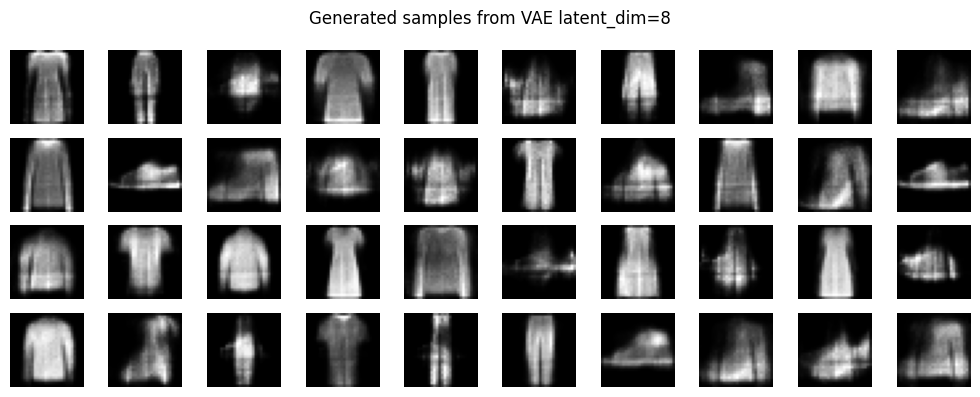

Saved: results_hw05/problem3_generated_samples_latent_8.png
VAE latent 8 {'sample_count': 1000, 'mean_confidence': 0.6846079230308533, 'median_confidence': 0.6944820284843445, 'high_confidence_threshold': 0.8, 'high_confidence_rate': 0.3720000088214874, 'coverage_class_count': 10, 'class_entropy': 2.021104574203491, 'normalized_class_entropy': 0.8777545517368346, 'class_counts': [208, 58, 206, 112, 16, 20, 8, 119, 136, 117], 'class_distribution': [0.20800000429153442, 0.057999998331069946, 0.20600000023841858, 0.1120000034570694, 0.01600000075995922, 0.019999999552965164, 0.00800000037997961, 0.11900000274181366, 0.13600000739097595, 0.11699999868869781]}


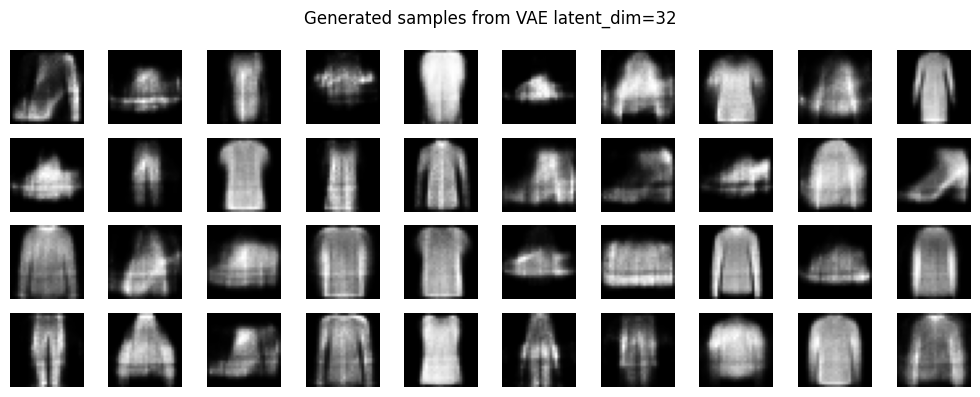

Saved: results_hw05/problem3_generated_samples_latent_32.png
VAE latent 32 {'sample_count': 1000, 'mean_confidence': 0.6732165813446045, 'median_confidence': 0.673206627368927, 'high_confidence_threshold': 0.8, 'high_confidence_rate': 0.33500000834465027, 'coverage_class_count': 10, 'class_entropy': 1.991668462753296, 'normalized_class_entropy': 0.864970611142853, 'class_counts': [193, 57, 250, 76, 26, 10, 11, 104, 149, 124], 'class_distribution': [0.19300000369548798, 0.05700000002980232, 0.25, 0.07599999755620956, 0.026000000536441803, 0.009999999776482582, 0.010999999940395355, 0.10400000214576721, 0.14900000393390656, 0.12399999797344208]}
Saved: results_hw05/problem3_classifier_based_evaluation.json


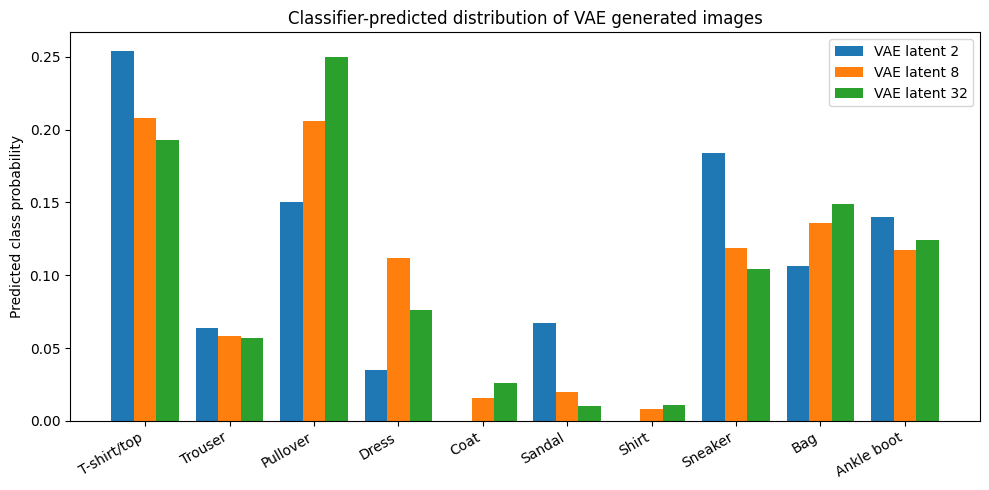

Saved: results_hw05/problem3_generated_class_distribution.png


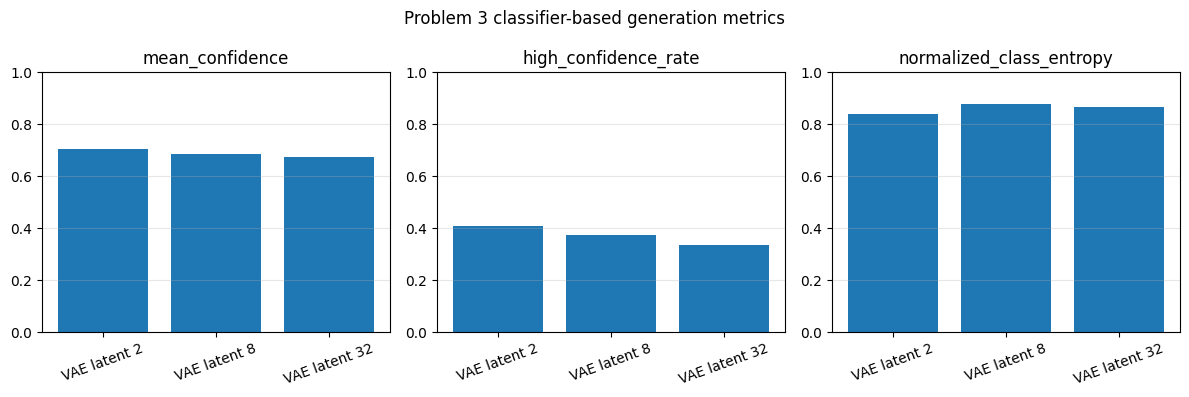

Saved: results_hw05/problem3_generation_metric_bars.png


{'VAE latent 2': {'sample_count': 1000,
  'mean_confidence': 0.7033578157424927,
  'median_confidence': 0.7324241995811462,
  'high_confidence_threshold': 0.8,
  'high_confidence_rate': 0.40799999237060547,
  'coverage_class_count': 8,
  'class_entropy': 1.9316542148590088,
  'normalized_class_entropy': 0.8389067548087328,
  'class_counts': [254, 64, 150, 35, 0, 67, 0, 184, 106, 140],
  'class_distribution': [0.2540000081062317,
   0.06400000303983688,
   0.15000000596046448,
   0.03500000014901161,
   0.0,
   0.06700000166893005,
   0.0,
   0.18400000035762787,
   0.10599999874830246,
   0.14000000059604645]},
 'VAE latent 8': {'sample_count': 1000,
  'mean_confidence': 0.6846079230308533,
  'median_confidence': 0.6944820284843445,
  'high_confidence_threshold': 0.8,
  'high_confidence_rate': 0.3720000088214874,
  'coverage_class_count': 10,
  'class_entropy': 2.021104574203491,
  'normalized_class_entropy': 0.8777545517368346,
  'class_counts': [208, 58, 206, 112, 16, 20, 8, 119, 136

In [11]:
CLASSIFIER_EPOCHS = experiment_epochs(5)
CLASSIFIER_LR = 1e-3
CLASSIFIER_WEIGHT_DECAY = 1e-4
GENERATED_SAMPLE_COUNT = 1000 if not COLAB_FAST_DEV_RUN else 64
GENERATION_BATCH_SIZE = experiment_batch_size(256)

classifier_model: FashionMNISTClassifier | None = None
classifier_history: dict = {}
problem3_metrics: dict[str, dict] = {}

if RUN_PROBLEM_3:
    if not vae_models:
        raise RuntimeError("Run Problem 2 first so that vae_models contains trained VAE models.")

    classifier_model, classifier_history = train_classifier(
        epochs=CLASSIFIER_EPOCHS,
        learning_rate=CLASSIFIER_LR,
        weight_decay=CLASSIFIER_WEIGHT_DECAY,
    )

    generated_examples: dict[str, torch.Tensor] = {}
    for latent_dim, vae_model in vae_models.items():
        name = f"VAE latent {latent_dim}"
        generated_images = generate_vae_images(
            model=vae_model,
            latent_dim=latent_dim,
            sample_count=GENERATED_SAMPLE_COUNT,
            batch_size=GENERATION_BATCH_SIZE,
        )
        generated_examples[name] = generated_images
        metrics = evaluate_generated_images_with_classifier(
            classifier=classifier_model,
            images=generated_images,
            batch_size=GENERATION_BATCH_SIZE,
            confidence_threshold=0.8,
        )
        problem3_metrics[name] = metrics
        plot_generated_samples(
            images=generated_images,
            path=output_dir / f"problem3_generated_samples_latent_{latent_dim}.png",
            title=f"Generated samples from VAE latent_dim={latent_dim}",
        )
        print(name, metrics)

    save_json(
        {
            "discussion_summary": {
                "quality": "Generated images should look like real FashionMNIST samples and be classified with high confidence.",
                "diversity": "Generated images should not repeat one pattern and should cover many classes and shapes.",
                "coverage": "Generated images should be distributed across the classes or modes present in real data.",
            },
            "evaluation_method": "Classifier-based evaluation",
            "classifier_history": classifier_history,
            "generated_metrics": problem3_metrics,
        },
        output_dir / "problem3_classifier_based_evaluation.json",
    )
    plot_class_distribution(
        metrics_by_name=problem3_metrics,
        path=output_dir / "problem3_generated_class_distribution.png",
    )
    plot_problem3_metric_bars(
        metrics_by_name=problem3_metrics,
        path=output_dir / "problem3_generation_metric_bars.png",
    )

problem3_metrics


### 문제 3 분석 초안

- 품질(Quality)은 classifier의 `mean_confidence`와 `high_confidence_rate`로 해석한다. 생성 이미지가 실제 FashionMNIST와 유사하고 클래스 특징이 뚜렷하다면 classifier가 높은 확률로 한 클래스를 선택한다.
- 다양성(Diversity)은 예측 class distribution과 `normalized_class_entropy`로 해석한다. 특정 class에만 몰리면 entropy가 낮고, 여러 class로 고르게 분포하면 entropy가 높다.
- 커버리지(Coverage)는 `coverage_class_count`와 class distribution으로 해석한다. 10개 class 중 몇 개 class가 생성 결과에서 관찰되는지 확인한다.
- 이 방법의 장점은 수치화가 쉽고 자동 평가가 가능하다는 점이다. 또한 classifier test accuracy를 함께 확인해 평가 도구 자체가 FashionMNIST를 잘 구분하는지 검증할 수 있다.
- 한계는 classifier가 틀리거나 과신할 수 있다는 점이다. 높은 confidence가 항상 사람이 보기에 좋은 이미지를 의미하지는 않으며, 같은 class 안의 세부 mode 다양성까지 충분히 측정하지 못한다.
- 최종 보고서에서는 `problem3_classifier_based_evaluation.json`, generated sample grid, class distribution plot, metric bar plot을 근거로 품질/다양성/커버리지를 각각 서술한다.
